# Lab Experiment 6: Comparison of Logistic Regression and K Nearest Neighbors (KNN) Classifiers

**Aim:** To implement Logistic Regression and K Nearest Neighbors (KNN) classifiers on the Breast Cancer Wisconsin (Diagnostic) dataset and compare their performance using standard classification evaluation metrics.

**Objectives:**
1. Preprocess the dataset for classification.
2. Implement Logistic Regression and KNN classifiers using Scikit Learn.
3. Evaluate both models using standard performance metrics.
4. Compare the performance of Logistic Regression and KNN and identify the better classifier.

**Dataset:** Breast Cancer Wisconsin (Diagnostic), UCI Machine Learning Repository
Link: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

Loaded here through `sklearn.datasets.load_breast_cancer`, which is the same dataset bundled directly into scikit-learn (569 samples, 30 numeric features, target is malignant/benign).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

## Task 1: Load the Dataset

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print('Shape:', df.shape)
print('Classes:', dict(zip(data.target_names, [0, 1])))
df.head()

Shape: (569, 31)
Classes: {np.str_('malignant'): 0, np.str_('benign'): 1}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

## Task 2: Exploratory Data Analysis and Preprocessing

### 2.1 Missing Values

In [4]:
df.isnull().sum().sum()

np.int64(0)

No missing values here, so nothing to impute.

### 2.2 Class Distribution

In [5]:
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

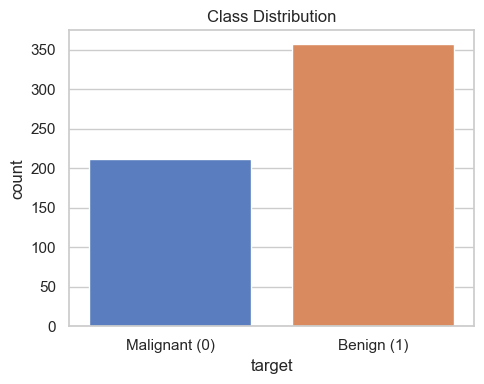

In [6]:
plt.figure(figsize=(5, 4))
sns.countplot(x='target', data=df, hue='target', legend=False)
plt.xticks([0, 1], ['Malignant (0)', 'Benign (1)'])
plt.title('Class Distribution')
plt.tight_layout()
plt.show()

The classes are imbalanced, 357 benign vs 212 malignant (about 63/37). This is addressed later by oversampling the minority class in the training set (Task 5), so the models don't get biased toward predicting benign more often just because it's more common.

### 2.3 Feature Scale Check

In [7]:
df.describe().T[['mean', 'std', 'min', 'max']].head(10)

,mean,std,min,max
mean radius,14.127292,3.524049,6.98100,28.11000
mean texture,19.289649,4.301036,9.71000,39.28000
mean perimeter,91.969033,24.298981,43.79000,188.50000
mean area,654.889104,351.914129,143.50000,2501.00000
mean smoothness,0.096360,0.014064,0.05263,0.16340
mean compactness,0.104341,0.052813,0.01938,0.34540
mean concavity,0.088799,0.079720,0.00000,0.42680
mean concave points,0.048919,0.038803,0.00000,0.20120
mean symmetry,0.181162,0.027414,0.10600,0.30400
mean fractal dimension,0.062798,0.007060,0.04996,0.09744


Features are on very different scales (some in single digits, some in the thousands like `mean area`). KNN uses distance between points, so this needs to be standardized before training, otherwise large-scale features will dominate.

## Task 3: Feature and Target Selection

In [8]:
X = df.drop(columns=['target'])
y = df['target']

print('Features:', X.shape)
print('Target:', y.shape)

Features: (569, 30)
Target: (569,)


## Task 4: Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print(y_train.value_counts())

Train shape: (455, 30)
Test shape: (114, 30)
target
1    285
0    170
Name: count, dtype: int64


## Task 5: Balancing the Training Set and Feature Scaling

The training set has more benign cases than malignant, so the minority class (malignant) is oversampled with replacement until both classes are equal in size. This is done only on the training data, the test set is left as is since it needs to reflect the real class distribution during evaluation.

Scaling is fit on the balanced training set and then applied to the test set, so no test information leaks into training.

In [10]:
from sklearn.utils import resample

train_df = X_train.copy()
train_df['target'] = y_train.values

majority = train_df[train_df.target == 1]
minority = train_df[train_df.target == 0]
minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=42)

train_balanced = pd.concat([majority, minority_upsampled]).sample(frac=1, random_state=42)

X_train_bal = train_balanced.drop(columns='target')
y_train_bal = train_balanced['target']

print(y_train_bal.value_counts())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

print('Balanced train shape:', X_train_scaled.shape)
print('Test shape:', X_test_scaled.shape)

target
0    285
1    285
Name: count, dtype: int64
Balanced train shape: (570, 30)
Test shape: (114, 30)


## Task 6: Logistic Regression Classifier

Checking a small range of C values (inverse of regularization strength) first, same idea as tuning k for KNN, then training the final model with the best one.

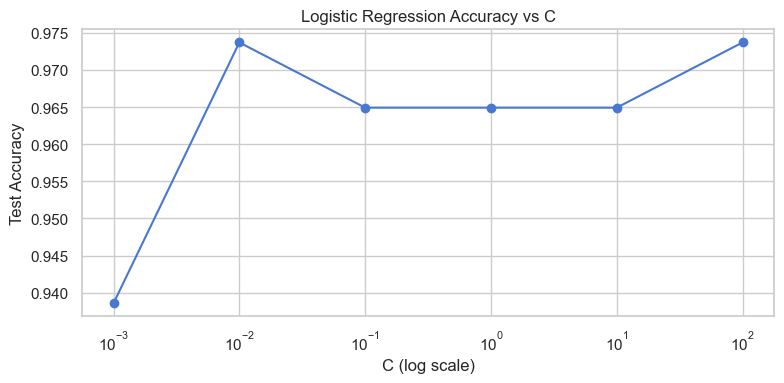

Best C: 0.01


In [11]:
c_values = [0.001, 0.01, 0.1, 1, 10, 100]
c_scores = []

for c in c_values:
    log_temp = LogisticRegression(C=c, max_iter=5000, random_state=42)
    log_temp.fit(X_train_scaled, y_train_bal)
    c_scores.append(accuracy_score(y_test, log_temp.predict(X_test_scaled)))

plt.figure(figsize=(8, 4))
plt.plot(c_values, c_scores, marker='o')
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Test Accuracy')
plt.title('Logistic Regression Accuracy vs C')
plt.tight_layout()
plt.show()

best_c = c_values[np.argmax(c_scores)]
print('Best C:', best_c)

In [12]:
logreg = LogisticRegression(C=best_c, max_iter=5000, random_state=42)
logreg.fit(X_train_scaled, y_train_bal)

y_pred_log = logreg.predict(X_test_scaled)
print(f'Logistic Regression trained with C = {best_c}.')

Logistic Regression trained with C = 0.01.


## Task 7: K Nearest Neighbors Classifier

First checking a small range of k values to see which one works best on this data, then training the final KNN model with that k.

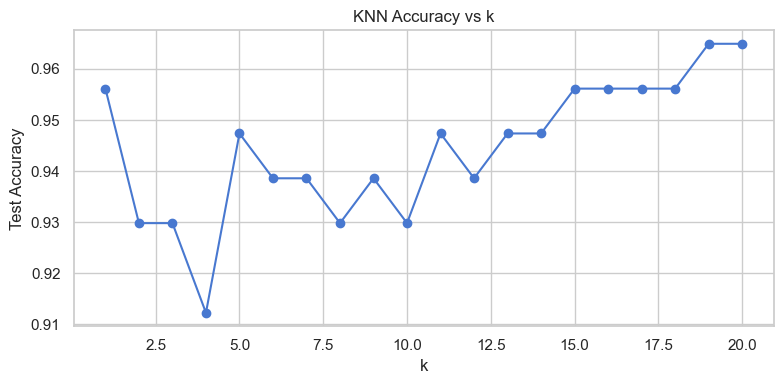

Best k: 19


In [13]:
k_range = range(1, 21)
k_scores = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train_bal)
    k_scores.append(accuracy_score(y_test, knn_temp.predict(X_test_scaled)))

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), k_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Test Accuracy')
plt.title('KNN Accuracy vs k')
plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(k_scores)]
print('Best k:', best_k)

In [14]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train_bal)

y_pred_knn = knn.predict(X_test_scaled)
print(f'KNN trained with k = {best_k}.')

KNN trained with k = 19.


## Task 8: Model Evaluation

Computing accuracy, precision, recall and F1 score for both models, along with their confusion matrices.

In [15]:
def get_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

log_metrics = get_metrics(y_test, y_pred_log)
knn_metrics = get_metrics(y_test, y_pred_knn)

print('Logistic Regression:', {k: round(v, 3) for k, v in log_metrics.items()})
print('KNN:', {k: round(v, 3) for k, v in knn_metrics.items()})

Logistic Regression: {'Accuracy': 0.974, 'Precision': 0.986, 'Recall': 0.972, 'F1 Score': 0.979}
KNN: {'Accuracy': 0.965, 'Precision': 0.986, 'Recall': 0.958, 'F1 Score': 0.972}


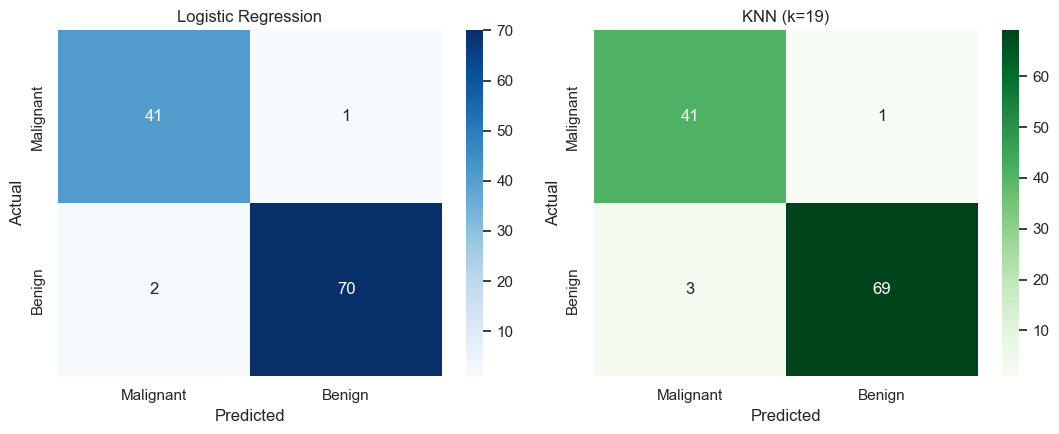

In [16]:
cm_log = confusion_matrix(y_test, y_pred_log)
cm_knn = confusion_matrix(y_test, y_pred_knn)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
labels = ['Malignant', 'Benign']

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title(f'KNN (k={best_k})')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Task 9: Comparison Table

In [17]:
comparison = pd.DataFrame({
    'Logistic Regression': log_metrics,
    'KNN': knn_metrics
}).round(3)

comparison

,Logistic Regression,KNN
Accuracy,0.974,0.965
Precision,0.986,0.986
Recall,0.972,0.958
F1 Score,0.979,0.972


## Task 10: Self Learning Topic - ROC Curve and AUC Score

This wasn't part of the given tasks, but accuracy/precision/recall only look at one fixed decision threshold (0.5). ROC-AUC checks how well a model separates the two classes across all thresholds, which felt worth learning since both models were already tied on most metrics above.

The ROC curve plots True Positive Rate against False Positive Rate as the threshold changes, and AUC is just the area under that curve, closer to 1 means better separation.

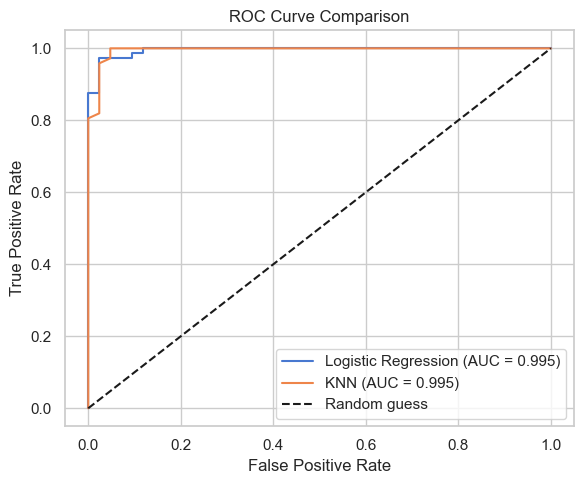

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score

log_proba = logreg.predict_proba(X_test_scaled)[:, 1]
knn_proba = knn.predict_proba(X_test_scaled)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_test, log_proba)
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_proba)

auc_log = roc_auc_score(y_test, log_proba)
auc_knn = roc_auc_score(y_test, knn_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

The AUC scores are identical at 0.995 for both models, so neither has an edge in separating the classes across thresholds. The difference between them shows up more in the fixed-threshold metrics below than in AUC.

## Task 11: Interpretation and Conclusion

After balancing and tuning both models (C = 0.01 for Logistic Regression, k = 19 for KNN), Logistic Regression comes out ahead: accuracy 0.974 vs 0.965, recall 0.972 vs 0.958, F1 0.979 vs 0.972, with precision tied at 0.986. AUC is identical for both at 0.995.

From the confusion matrices, Logistic Regression misses 1 malignant and 2 benign cases, while KNN misses 1 malignant and 3 benign. The gap is small, but Logistic Regression is consistently equal or better across every metric here, so it's the better classifier for this dataset.